In [5]:
""" Import section """
import pandas as pd
import matplotlib.pyplot as plt

# Opening files to analyze

In [6]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

In [38]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso  = create_combined_dataframe("dataset_t6_grouped/results/G0")
dmso.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso_highest_pbopdy = dmso.loc[dmso.groupby('image')['pbody_number'].idxmax()]
dmso_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
582,W0082F0002T0006Z000C1N151.png,14,30.166926,30.384852,17.621077,18.370207,DMSO,DMSO
523,W0082F0002T0006Z000C1N152.png,9,15.299378,17.473632,12.196866,13.832065,DMSO,DMSO
460,W0082F0002T0006Z000C1N153.png,4,21.716317,21.321122,19.366809,19.695328,DMSO,DMSO
308,W0082F0002T0006Z000C1N154.png,14,52.811247,53.188336,14.195958,14.128291,DMSO,DMSO
560,W0082F0002T0006Z000C1N156.png,9,45.651831,46.132974,10.033206,10.234657,DMSO,DMSO
739,W0082F0002T0006Z000C1N162.png,13,9.016816,8.400369,18.860760,20.080911,DMSO,DMSO
159,W0082F0002T0006Z000C1N19.png,7,63.970563,61.147552,12.358747,11.443836,DMSO,DMSO
684,W0082F0002T0006Z000C1N21.png,8,53.912650,55.723348,10.914597,10.558391,DMSO,DMSO
123,W0082F0002T0006Z000C1N30.png,7,62.780625,58.832797,9.280097,15.590544,DMSO,DMSO
909,W0082F0002T0006Z000C1N35.png,17,41.839969,41.666434,9.760894,9.811727,DMSO,DMSO


## Group 1

In [8]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1  = create_combined_dataframe("dataset_t6_grouped/results/G1")
# g1.head(50)

In [9]:
""" check for nan values on g1 dataframe """
g1.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [10]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2  = create_combined_dataframe("dataset_t6_grouped/results/G2")
# g2.head(50)


In [11]:
""" check for nan values on g2 dataframe """
g2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [12]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3  = create_combined_dataframe("dataset_t6_grouped/results/G3")
# g3.head(50)

In [13]:
""" check for nan values on g3 dataframe """
g3.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [14]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4  = create_combined_dataframe("dataset_t6_grouped/results/G4")
# g4.head(50)

In [15]:
""" check for nan values on g4 dataframe """
g4.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [16]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5  = create_combined_dataframe("dataset_t6_grouped/results/G5")
# g5.head(50)

In [17]:
""" check for nan values on g1 dataframe """
g5.isna().sum()

image            0
pbody_number     0
dist_nuclei     95
dist_mito        0
nuclei_std      95
mito_std         0
medicine         0
group            0
dtype: int64

# Graphing Section

In [19]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [23]:
""" Calling function for each dataframe """
group_summary, med_summary, combined_df = summarize_pbodies_by_group(dmso, g1, g2, g3, g4, g5)
group_summary.head(50)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,910,37.644022,35.330905,17.473040,17.331990
1,G1,1486,32.502657,29.817761,16.784150,16.022025
2,G2,2963,33.930727,33.009990,17.456573,17.135764
3,G3,1320,43.079189,41.130336,21.145230,21.348172
4,G4,7149,37.829421,34.953191,18.533707,18.679874
5,G5,5512,35.262373,29.232626,26.448808,24.425268


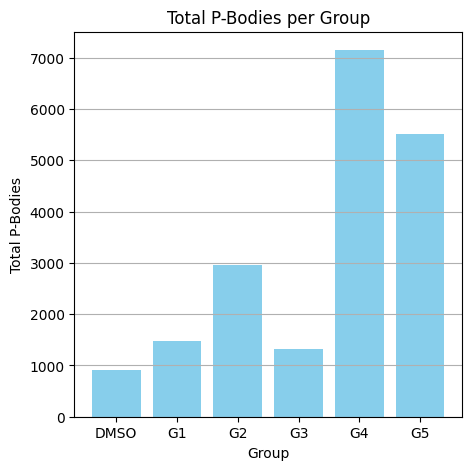

In [26]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary['group'], group_summary['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary['group'])
plt.grid(axis='y')
plt.show()